<a href="https://colab.research.google.com/github/ahmedinB/Extrapolation/blob/main/extrapolatecomp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Extrapolation in different models

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


Def Train_and_Plot(model, epoch,  optimizer, loss)

In [ ]:
# @title
def Train_and_Plot(model, epoch, optimizer, loss_fn):

  for e in range(epoch):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x_train.unsqueeze(1))
    loss = loss_fn(y_pred, y_train.unsqueeze(1))
    loss.backward()
    optimizer.step()

    model.eval()

  with torch.inference_mode():
    y_val_pred = model(x_val.unsqueeze(1))
    val_loss = loss_fn(y_val_pred, y_val.unsqueeze(1))

  print(loss.item(), "Training error")
  print(val_loss.item(), "Validation error")
  plt.figure(figsize=(10, 6))
  plt.scatter(x_train, y_train, s=10, label='Train Data', alpha=0.6)
  plt.scatter(x_val, y_val, s=10, label='Validation Data', alpha=0.6)
  plt.plot(x_val, y_val_pred.detach(), label='Model Predictions')
  plt.title('Model Performance: Extrapolation on Validation Data')
  plt.xlabel('X Value')
  plt.ylabel('Y Value')
  plt.legend()
  plt.grid(True)
  plt.show()

Testing Extrapolation of MLP, Mamba, Transformer and RNN

0.026447247713804245 Training error
3.7306485176086426 Validation error


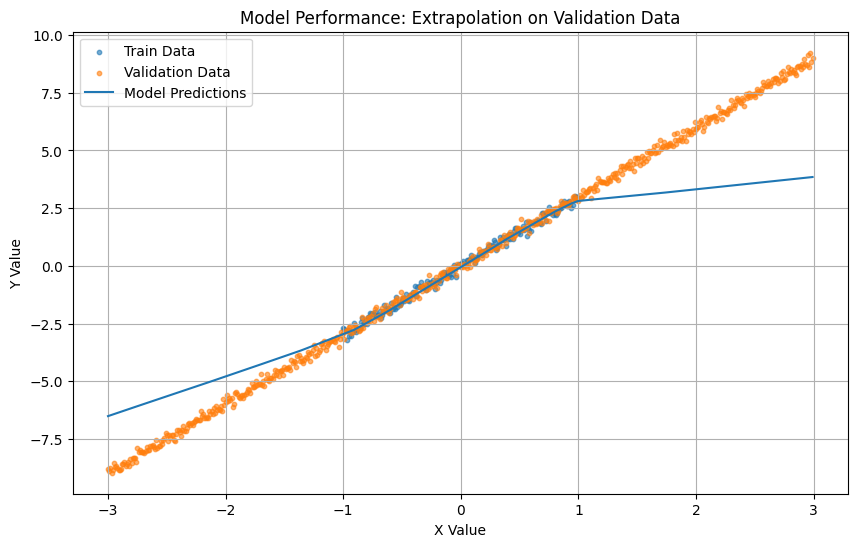

In [ ]:
torch.manual_seed(42)
x_train, x_val = torch.arange(-1, 1, 0.01), torch.arange(-3, 3, 0.01)

y_train = 3 * x_train + torch.normal(0, 1, x_train.shape) * 0.15
y_val = 3 * x_val + torch.normal(0, 1, x_val.shape) * 0.15

model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05)
loss_fn = nn.MSELoss()

Train_and_Plot(model, epoch = 500, optimizer = optimizer, loss_fn = loss_fn)

MLP does not extrapolate well with activation functions


0.021553518250584602 Training error
0.02100159227848053 Validation error


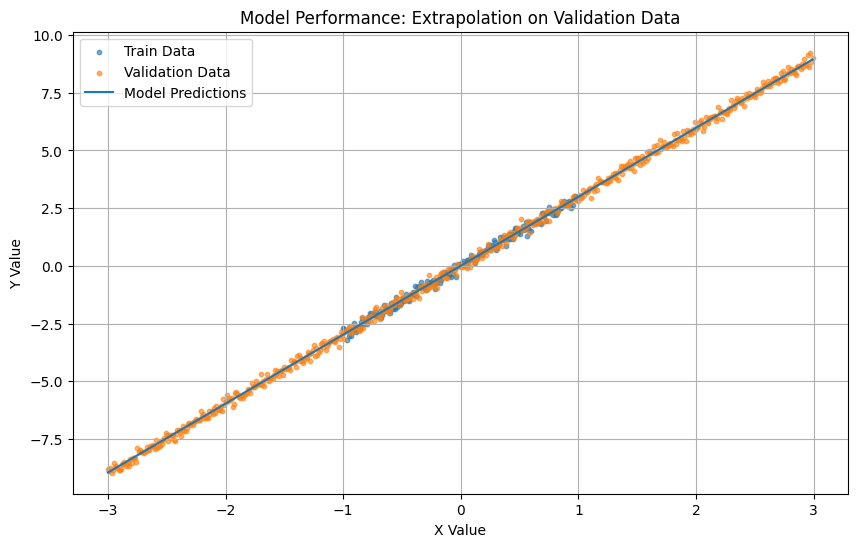

In [ ]:
# MLP without ReLU
model = nn.Sequential(
    nn.Linear(1, 16),
    # nn.ReLU(),
    nn.Linear(16, 16),
    # nn.ReLU(),
    nn.Linear(16, 1)
)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05)
loss_fn = nn.MSELoss()

Train_and_Plot(model, epoch = 500, optimizer = optimizer, loss_fn = loss_fn)

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x): # x shape: (batch_size, seq_len, embed_dim)
        batch_size, seq_len, _ = x.shape

        # Project Q, K, V and reshape for multi-head attention
        q = self.q_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Calculate attention scores
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        # Apply softmax to get attention weights
        attn_weights = F.softmax(attn_scores, dim=-1)

        # Apply attention weights to V
        attn_output = torch.matmul(attn_weights, v)

        # Concatenate heads and project back to embed_dim
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)

        output = self.out_proj(attn_output)
        return output

class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(ff_dim, embed_dim)

    def forward(self, x): # x shape: (batch_size, seq_len, embed_dim)
        return self.linear2(self.relu(self.linear1(x)))

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)

        self.feed_forward = FeedForward(embed_dim, ff_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x): # x shape: (batch_size, seq_len, embed_dim)
        # Self-attention part with residual connection and layer norm
        attn_output = self.attention(x)
        x = x + self.dropout1(attn_output)
        x = self.norm1(x)

        # Feed-forward part with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = x + self.dropout2(ff_output)
        x = self.norm2(x)
        return x

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.output_layer = nn.Linear(embed_dim, 1)

    def forward(self, x): # x shape: (batch_size, input_dim)
        # Reshape x to (batch_size, 1, input_dim) to simulate a sequence of length 1
        x = x.unsqueeze(1)

        # Embed the input
        x = self.embedding(x)

        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Take the output of the single token and pass through the final linear layer
        x = x.squeeze(1) # (batch_size, embed_dim)
        output = self.output_layer(x)
        return output

print("Simplified Transformer Model classes (MultiHeadSelfAttention, FeedForward, TransformerBlock, TransformerRegressor) defined.")

Simplified Transformer Model classes (MultiHeadSelfAttention, FeedForward, TransformerBlock, TransformerRegressor) defined.


0.020935848355293274 Training error
5.372799873352051 Validation error


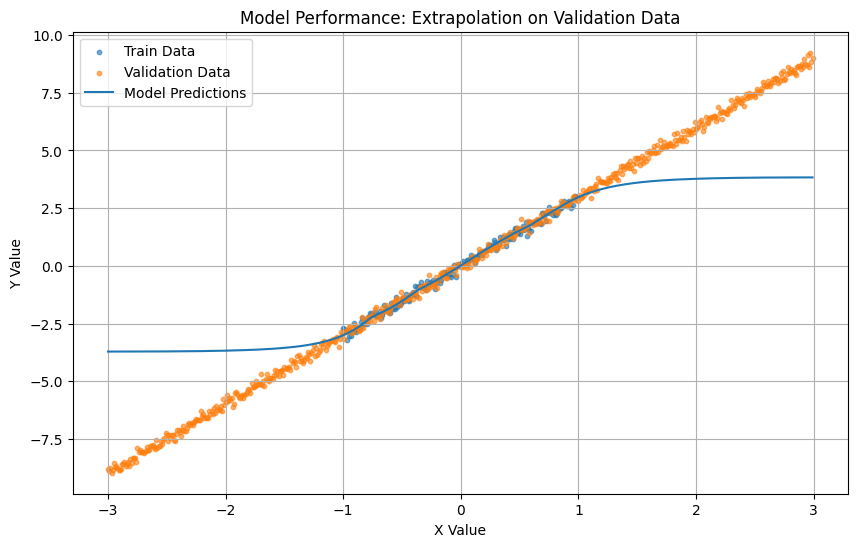

In [ ]:
model = TransformerRegressor(input_dim=1, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
Train_and_Plot(model, epoch=500, optimizer=optimizer, loss_fn=loss_fn)

0.06004694849252701 Training error
7.335690975189209 Validation error


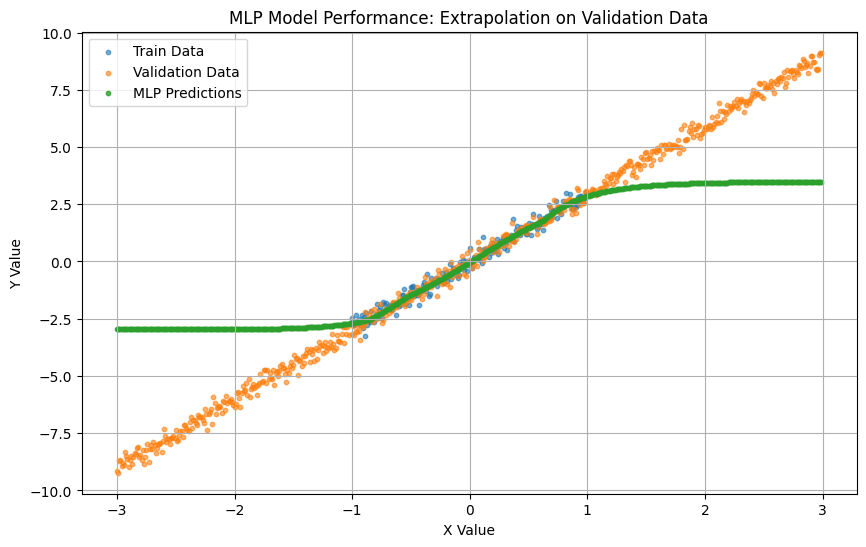

In [ ]:
# without feed forward layer
model = TransformerRegressor(input_dim=1, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
Train_and_Plot(model, epoch=500, optimizer=optimizer, loss_fn=loss_fn)

0.060626592487096786 Training error
8.23133659362793 Validation error


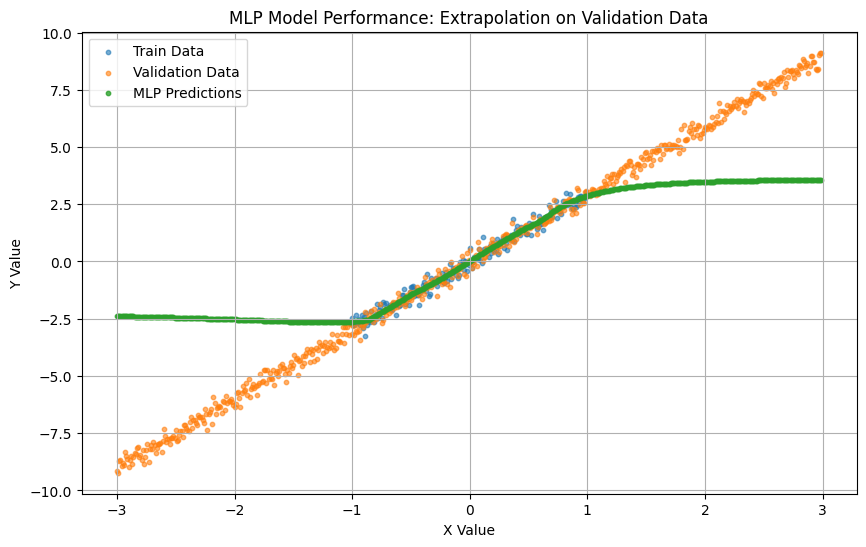

In [ ]:
# with feed forward layer

model = TransformerRegressor(input_dim=1, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

Train_and_Plot(model, epoch=500, optimizer=optimizer, loss_fn=loss_fn)

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerEncoderRegressor(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        # Embedding layer to map input_dim to embed_dim
        self.embedding = nn.Linear(input_dim, embed_dim)

        # TransformerEncoderLayer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=False # Input will be (seq_len, batch_size, features)
        )

        # TransformerEncoder
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # Final linear output layer for regression
        self.output_layer = nn.Linear(embed_dim, 1)

    def forward(self, x): # x shape: (batch_size, input_dim)
        # Reshape x to (seq_len, batch_size, input_dim). For single feature input, seq_len is 1.
        x = x.unsqueeze(0) # Becomes (1, batch_size, input_dim)

        # Embed the input
        x = self.embedding(x)

        # Pass through TransformerEncoder
        # TransformerEncoder expects (seq_len, batch_size, embed_dim)
        transformer_output = self.transformer_encoder(x)

        # Take the output corresponding to the 'sequence' part (which is still 1 here)
        # and pass through the final linear layer.
        # transformer_output shape: (1, batch_size, embed_dim)
        output = self.output_layer(transformer_output.squeeze(0)) # Squeeze seq_len dimension
        return output

print("TransformerEncoderRegressor class defined.")

TransformerEncoderRegressor class defined.


In [ ]:
model_transformer_encoder = TransformerEncoderRegressor(input_dim=1, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2)
optimizer_transformer_encoder = torch.optim.Adam(model_transformer_encoder.parameters(), lr=0.001)
loss_fn_transformer_encoder = nn.MSELoss()

print("TransformerEncoderRegressor model, Adam optimizer, and MSE loss function initialized.")

TransformerEncoderRegressor model, Adam optimizer, and MSE loss function initialized.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerEncoderRegressor(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        # Embedding layer to map input_dim to embed_dim
        self.embedding = nn.Linear(input_dim, embed_dim)

        # TransformerEncoderLayer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True # Set batch_first to True to align with common practices and avoid warning
        )

        # TransformerEncoder
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # Final linear output layer for regression
        self.output_layer = nn.Linear(embed_dim, 1)

    def forward(self, x): # x shape: (batch_size, input_dim)
        # For batch_first=True, input should be (batch_size, seq_len, input_dim)
        # Since seq_len is 1, we unsqueeze at dim 1
        x = x.unsqueeze(1) # Becomes (batch_size, 1, input_dim)

        # Embed the input
        x = self.embedding(x)

        # Pass through TransformerEncoder
        # TransformerEncoder expects (batch_size, seq_len, embed_dim) with batch_first=True
        transformer_output = self.transformer_encoder(x)

        # Take the output of the single token and pass through the final linear layer
        # transformer_output shape: (batch_size, 1, embed_dim)
        output = self.output_layer(transformer_output.squeeze(1)) # Squeeze seq_len dimension
        return output

print("TransformerEncoderRegressor class redefined with batch_first=True.")

TransformerEncoderRegressor class redefined with batch_first=True.


0.06427203863859177 Training error
7.529980659484863 Validation error


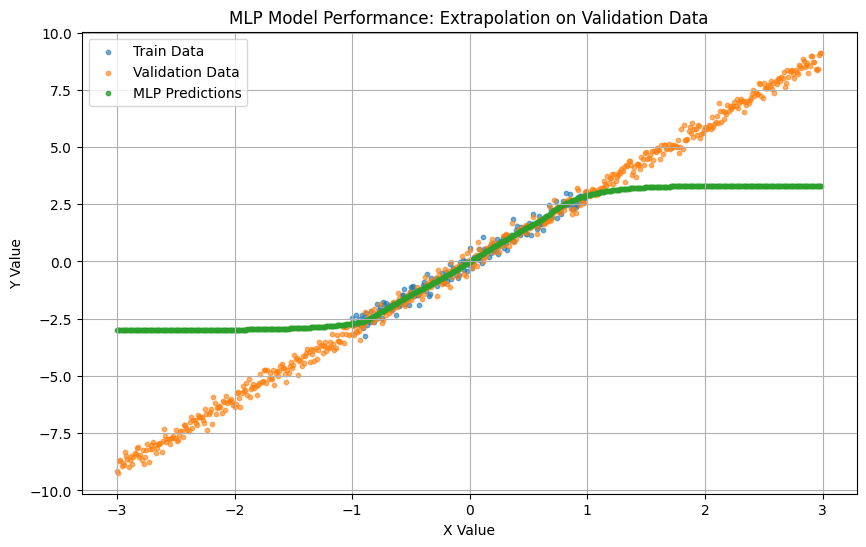

In [ ]:
model_transformer_encoder = TransformerEncoderRegressor(input_dim=1, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2)
optimizer_transformer_encoder = torch.optim.Adam(model_transformer_encoder.parameters(), lr=0.001)
loss_fn_transformer_encoder = nn.MSELoss()

Train_and_Plot(model_transformer_encoder, epoch=500, optimizer=optimizer_transformer_encoder, loss_fn=loss_fn_transformer_encoder)


In [ ]:
# @title
class RNNRegressor(nn.Module):
    def __init__(self, input_dim, hidden_size=64, num_layers=2):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=False
        )

        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x): # x shape: (batch_size, input_dim)
        # Reshape input for RNN: (batch_size, 1, input_dim) to represent a sequence of length 1
        x = x.unsqueeze(1)

        # Pass through the RNN layer
        # rnn_out shape: (batch_size, seq_len, hidden_size)
        # _h_n (hidden state) is not used for this simple regressor
        rnn_out, _ = self.rnn(x)

        # Squeeze the sequence length dimension from rnn_out
        # rnn_out shape becomes (batch_size, hidden_size)
        rnn_out = rnn_out.squeeze(1)

        # Pass through the linear output layer for regression prediction
        output = self.output_layer(rnn_out)
        return output

print("RNNRegressor class defined.")

RNNRegressor class defined.


0.02082798071205616 Training error
3.3111038208007812 Validation error


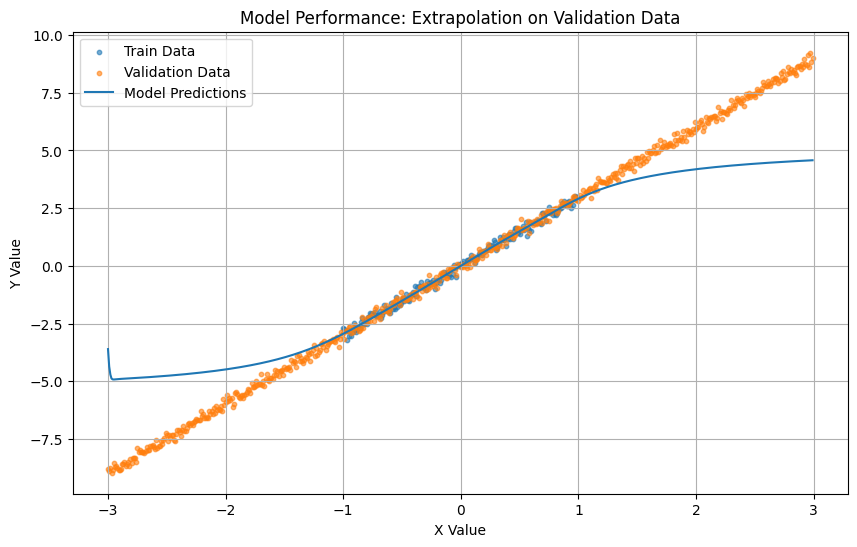

In [ ]:
model_rnn = RNNRegressor(input_dim=1, hidden_size=64, num_layers=2)
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)
loss_fn_rnn = nn.MSELoss()

Train_and_Plot(model_rnn, epoch=500, optimizer=optimizer_rnn, loss_fn=loss_fn_rnn)

0.021759742870926857 Training error
1.4999444484710693 Validation error


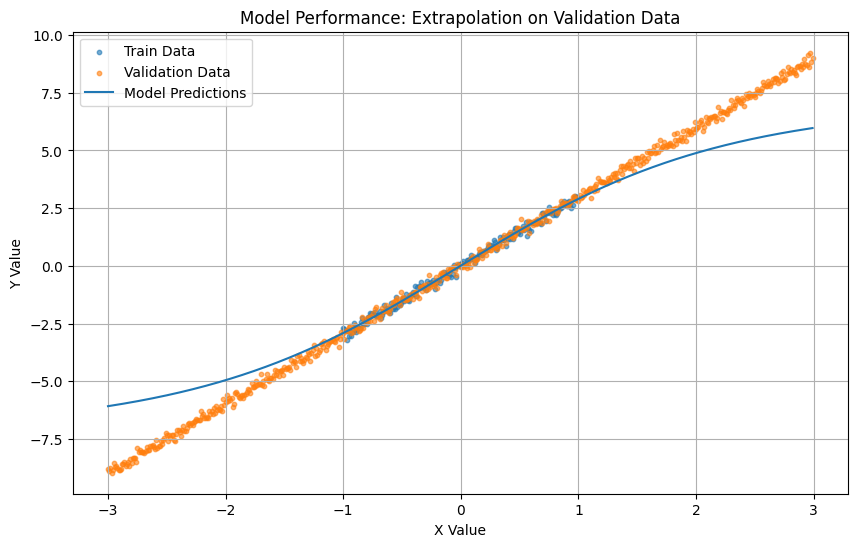

In [ ]:
model_rnn = RNNRegressor(input_dim=1, hidden_size=64, num_layers=2)
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)
loss_fn_rnn = nn.MSELoss()

Train_and_Plot(model_rnn, epoch=500, optimizer=optimizer_rnn, loss_fn=loss_fn_rnn)


In [ ]:
!pip install torch==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d mamba-ssm --no-build-isolation

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 101.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 136.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1

  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.5 MB/s eta 0:00:00
  Created wheel for causal-conv1d: filename=causal_conv1d-1.5.3.post1-cp312-cp312-linux_x86_64.whl size=151299921 sha256=ede850c09efb608705781bd2ae44a41f291a8006d158a4d28f6746e5a67cb1e2
  Stored in directory: /root/.cache/pip/wheels/50/b5/ee/ccdfcb7fa5da6970cb61695a3486c1cb4126e7050785c73ba3
  Created wheel for mamba-ssm: filename=mamba_ssm-2.2.6.post3-cp312-cp312-linux_x86_64.whl size=533241749 sha256=11249c2f3c4d9c2f6d297382fc6a233591d115afe80d3f8d645f5a64102cc158
  Stored in directory: /root/.cache/pip/wheels/a9/66/b0/91003b49a34b45995d1b34c7fd2c70cd998a23560e66f6817a
Successfully built causal-conv1d mamba-ssm


In [ ]:
# test mamba
from mamba_ssm import Mamba

batch, length, dim = 2, 64, 16
x = torch.randn(batch, length, dim).to("cuda")
model = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2).to("cuda")
y = model(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {y.shape}") #

Input shape: torch.Size([2, 64, 16])
Output shape: torch.Size([2, 64, 16])


0.2412908673286438 Training error
2.5831029415130615 Validation error


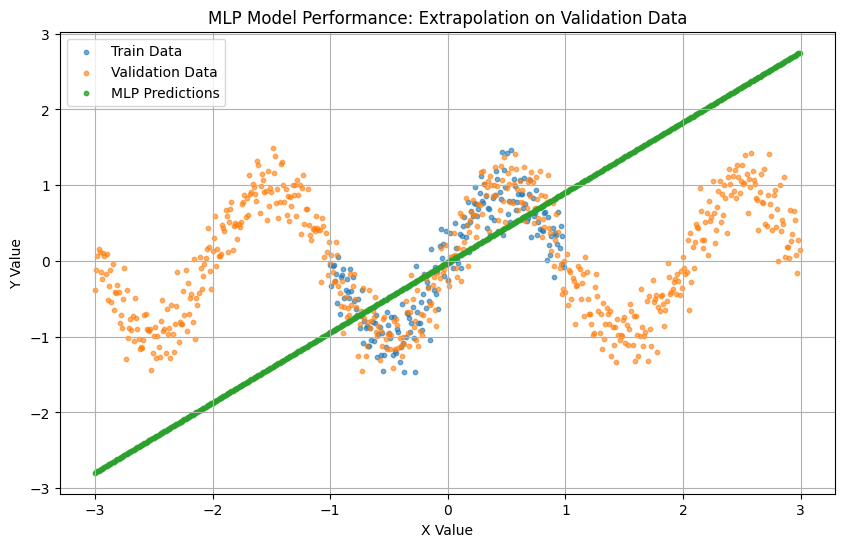

In [ ]:
x_train, x_val = torch.arange(-1, 1, 0.01), torch.arange(-3, 3, 0.01)
y_train, y_val = torch.sin(torch.pi * x_train) + torch.normal(0, 1, x_train.shape) * 0.25, torch.sin(torch.pi * x_val) + torch.normal(0, 1, x_val.shape) * 0.25

model = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05)
loss_fn = nn.MSELoss()

Train_and_Plot(model, epoch = 500, optimizer = optimizer, loss_fn = loss_fn)

0.02106431871652603 Training error
2.697988271713257 Validation error


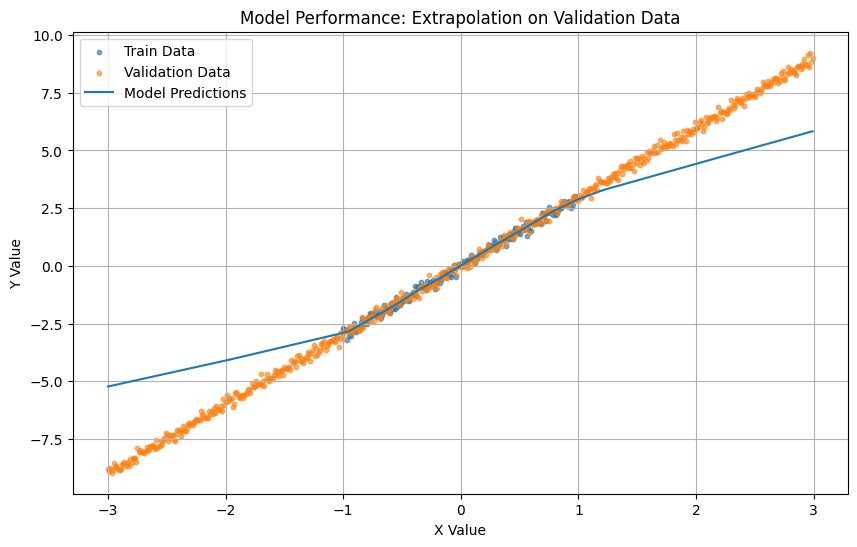

In [ ]:
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05)
loss_fn = nn.MSELoss()

Train_and_Plot(model, epoch = 1000, optimizer = optimizer, loss_fn = loss_fn)

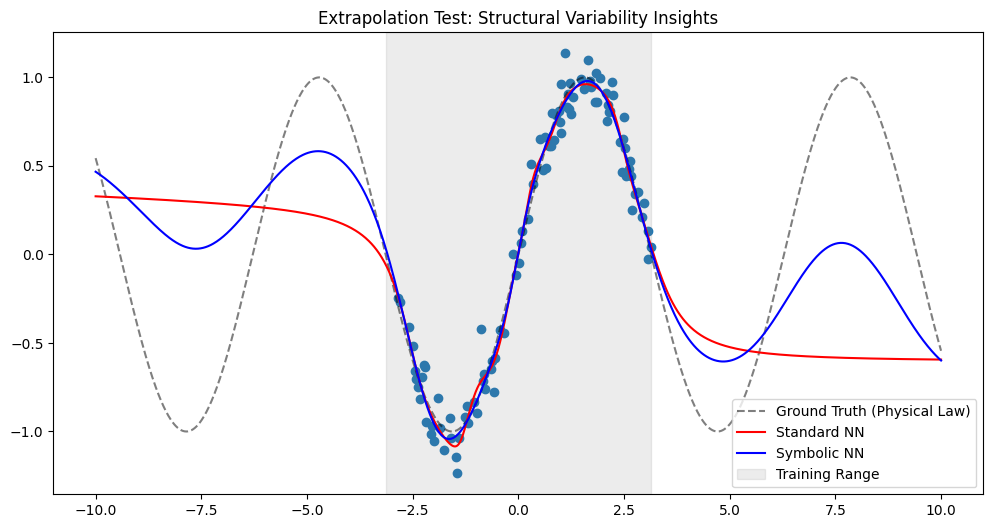

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class StandardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

class SymbolicNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        # manually inject the 'Physical Law' structure
        x_struct = torch.cat([x, torch.sin(x)], dim=-1)
        return self.net(x_struct)

x0 = torch.linspace(-np.pi, np.pi, 300).view(-1, 1)
y0 = torch.sin(x0) + torch.normal(0, 0.1, x0.shape)
x_test = torch.linspace(-10, 10, 1000).view(-1, 1)

num_samples = len(x0)
indices = torch.randperm(num_samples)

train_size = int(2/6 * num_samples)

x_shuffled = x0[indices]
y_shuffled = y0[indices]

x_train = x_shuffled[:train_size]
x_val = x_shuffled[train_size:]

y_train = y_shuffled[:train_size]
y_val = y_shuffled[train_size:]


someList = []
def train(model, x, y):
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(1000):
        loss = nn.MSELoss()(model(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        # if nn.MSELoss()(model(x_val), y_val) > loss:
        someList.append([nn.MSELoss()(model(x_val), y_val).item() , loss.item()])


std_model = StandardNN()
sym_model = SymbolicNN()
train(std_model, x_train, y_train)
train(sym_model, x_train, y_train)

plt.figure(figsize=(12, 6))
plt.scatter(x_train, y_train)
plt.plot(x_test, torch.sin(x_test), 'k--', alpha=0.5, label='Ground Truth (Physical Law)')
plt.plot(x_test, std_model(x_test).detach(), 'r-', label='Standard NN')
plt.plot(x_test, sym_model(x_test).detach(), 'b-', label='Symbolic NN')
plt.axvspan(-np.pi, np.pi, color='gray', alpha=0.15, label='Training Range')
plt.title("Extrapolation Test: Structural Variability Insights")
plt.legend()
plt.show()

Early stopping at epoch 360


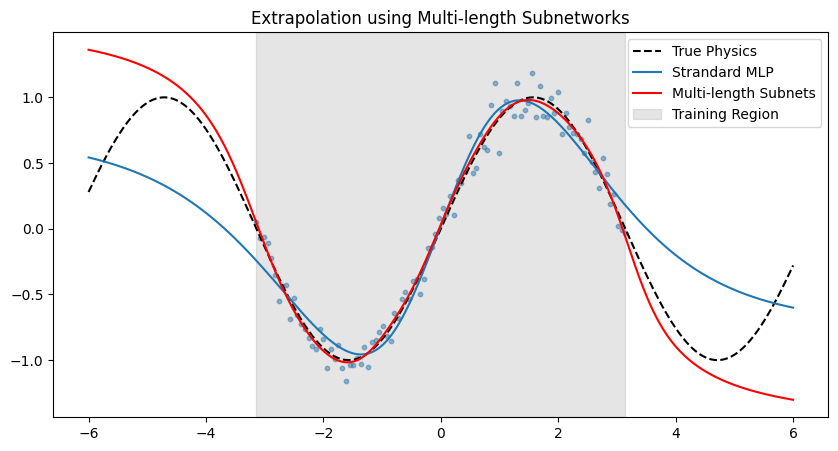

In [ ]:
# @title
# class StructuralVariabilityMLP(nn.Module):
#     def __init__(self, width=16):
#         super().__init__()
#         # Subnetwork 1: Order M1 (Short)
#         self.sub1 = nn.Sequential(
#             nn.Linear(1, width),
#             nn.Tanh(),
#             nn.Linear(width, 1)
#         )

#         # Subnetwork 2: Order M2 (Medium)
#         self.sub2 = nn.Sequential(
#             nn.Linear(1, width),
#             nn.Tanh(),
#             nn.Linear(width, width),
#             nn.Tanh(),
#             nn.Linear(width, 1)
#         )

#         # Subnetwork 3: Order M3 (Long)
#         self.sub3 = nn.Sequential(
#             nn.Linear(1, width),
#             nn.Tanh(),
#             nn.Linear(width, width),
#             nn.Tanh(),
#             nn.Linear(width, width),
#             nn.Tanh(),
#             nn.Linear(width, 1)
#         )

#     def forward(self, x):
#         # Linear combination of subnetworks
#         return self.sub1(x) + self.sub2(x) + self.sub3(x)

class LCNN(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        # Subnetwork 1: Shallow (captures simple patterns)
        self.sub1 = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

        # Subnetwork 2: Medium depth
        self.sub2 = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

        # Subnetwork 3: Deeper (captures complex patterns)
        self.sub3 = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

        # Learned combination weights
        self.alpha = nn.Parameter(torch.ones(3) / 3)

    def forward(self, x):
        outputs = torch.stack([
            self.sub1(x),
            self.sub2(x),
            self.sub3(x)
        ], dim=-1)
        weights = torch.softmax(self.alpha, dim=0)
        return (outputs * weights).sum(dim=-1)

x_train = torch.linspace(-torch.pi, torch.pi, 100).view(-1, 1)
y_train = torch.sin(x_train) + torch.normal(0, 0.10, x_train.shape)

model = LCNN(width=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

best_loss = float('inf')
patience = 20
trigger_times = 0

for epoch in range(500):
    model.train()
    pred = model(x_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Early stopping logic
    if loss.item() < best_loss:
        best_loss = loss.item()
        trigger_times = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    # print(epoch, loss.item(), best_loss, trigger_times, patience)

# --- Extrapolation Visualization ---
model.load_state_dict(torch.load('best_model.pth'))
x_test = torch.linspace(-6, 6, 500).view(-1, 1)
with torch.no_grad():
    y_pred = model(x_test)

std_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

optimizer = torch.optim.Adam(std_model.parameters(), lr = 0.001)
best_loss = float('inf')
patience = 20
trigger_times = 0

for _ in range(500):
  std_model.train()
  pred = std_model(x_train)
  loss = criterion(pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  # Early stopping logic
  if loss.item() < best_loss:
      best_loss = loss.item()
      trigger_times = 0
      # torch.save(std_model.state_dict(), 'best_std_model.pth')
  else:
      trigger_times += 1
      if trigger_times >= patience:
          print(f"Early stopping at epoch {epoch}")
          break
  # print(_, loss.item(), best_loss, trigger_times, patience)

plt.figure(figsize=(10, 5))
plt.plot(x_test, torch.sin(x_test), 'k--', label='True Physics')
plt.plot(x_test, std_model(x_test).detach(), label='Strandard MLP')
plt.plot(x_test, y_pred, 'r-', label='Multi-length Subnets')
plt.scatter(x_train, y_train, s = 10, alpha = 0.5 )
plt.axvspan(-torch.pi, torch.pi, color='gray', alpha=0.2, label='Training Region')
plt.title("Extrapolation using Multi-length Subnetworks")
plt.legend()
plt.show()

early stop std at 1583


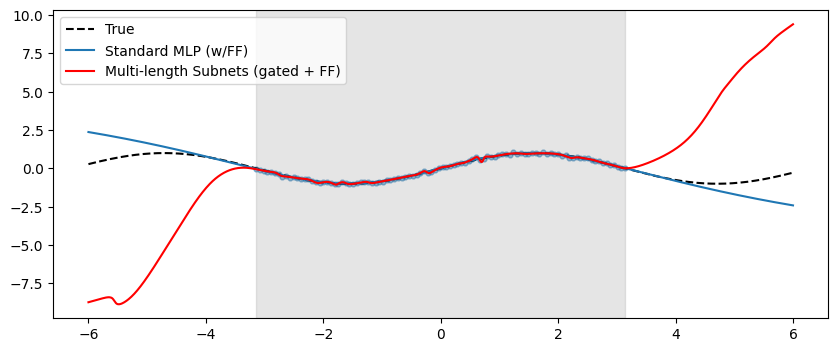

In [ ]:
# @title
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(0)

# optional: Fourier feature mapping
class FourierFeatures(nn.Module):
    def __init__(self, in_features=1, n_features=64, scale=1.0):
        super().__init__()
        self.B = nn.Parameter(torch.randn(in_features, n_features) * scale, requires_grad=False)
    def forward(self, x):
        # x: [N,1] -> [N, 2*n_features]
        xProj = x @ self.B  # [N, n_features]
        return torch.cat([torch.sin(xProj), torch.cos(xProj)], dim=-1)

class StructuralVariabilityMLP(nn.Module):
    def __init__(self, width=32, use_fourier=True, fourier_dim=32, fourier_scale=1.0):
        super().__init__()
        self.use_fourier = use_fourier
        if use_fourier:
            self.ff = FourierFeatures(1, n_features=fourier_dim, scale=fourier_scale)
            in_dim = 2 * fourier_dim
        else:
            in_dim = 1

        # Subnet short
        self.sub1 = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        # Subnet medium
        self.sub2 = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        # Subnet long
        self.sub3 = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

        # input-dependent gating network -> outputs three logits per input
        self.gate = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 3)   # logits for 3 subnets
        )

        # small linear skip from original x (helps tails)
        self.input_skip = nn.Linear(1, 1)

        # init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: [N,1]
        if self.use_fourier:
            xf = self.ff(x)   # [N, in_dim]
        else:
            xf = x
        o1 = self.sub1(xf)
        o2 = self.sub2(xf)
        o3 = self.sub3(xf)
        logits = self.gate(xf)           # [N,3]
        coeffs = torch.softmax(logits, dim=-1)  # [N,3]
        # weighted sum per input
        out = coeffs[:, 0:1]*o1 + coeffs[:, 1:2]*o2 + coeffs[:, 2:3]*o3
        out = out + self.input_skip(x)   # add skip
        return out

# Data
x_train = torch.linspace(-torch.pi, torch.pi, 100).view(-1,1)
y_train = torch.sin(x_train) + torch.randn_like(x_train)*0.05

# Create model
model = StructuralVariabilityMLP(width=64, use_fourier=True, fourier_dim=64, fourier_scale=1.0)
opt = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-6)
crit = nn.MSELoss()

# training with patience and saving best
best = 1e9
patience = 200
cnt = 0
for epoch in range(5000):
    model.train()
    pred = model(x_train)
    loss = crit(pred, y_train)
    opt.zero_grad(); loss.backward(); opt.step()
    if loss.item() < best:
        best = loss.item(); cnt = 0
        torch.save(model.state_dict(), 'best_comp.pth')
    else:
        cnt += 1
        if cnt >= patience:
            print("early stop comp at", epoch)
            break

# baseline comparable MLP (with same fourier front-end for fair comparison)
std = nn.Sequential(
    # FourierFeatures(1, n_features=64, scale=1.0),  # same features
    nn.Linear(1, 128),
    nn.Tanh(),
    nn.Linear(128, 128),
    nn.Tanh(),
    nn.Linear(128, 1)
)
# init
for m in std.modules():
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

opt2 = optim.Adam(std.parameters(), lr=5e-3, weight_decay=1e-6)
best2 = 1e9; cnt2 = 0
for epoch in range(5000):
    std.train()
    p = std(x_train)
    loss = crit(p, y_train)
    opt2.zero_grad(); loss.backward(); opt2.step()
    if loss.item() < best2:
        best2 = loss.item(); cnt2 = 0
        torch.save(std.state_dict(), 'best_std.pth')
    else:
        cnt2 += 1
        if cnt2 >= patience:
            print("early stop std at", epoch)
            break

# load and plot
model.load_state_dict(torch.load('best_comp.pth'))
std.load_state_dict(torch.load('best_std.pth'))
x_test = torch.linspace(-6,6,1000).view(-1,1)
with torch.no_grad():
    y_comp = model(x_test).cpu().numpy().squeeze()
    y_std  = std(x_test).cpu().numpy().squeeze()
plt.figure(figsize=(10,4))
plt.plot(x_test.numpy(), torch.sin(x_test).numpy(), 'k--', label='True')
plt.plot(x_test.numpy(), y_std, label='Standard MLP (w/FF)')
plt.plot(x_test.numpy(), y_comp, 'r-', label='Multi-length Subnets (gated + FF)')
plt.scatter(x_train.numpy(), y_train.numpy(), s=12, alpha=0.5)
plt.axvspan(-torch.pi, torch.pi, color='gray', alpha=0.2)
plt.legend(); plt.show()
